# Reconstruction d’une image scintigraphique cardiaque




---

# Table des Matières


### [1. Introduction](#1-Introduction)

### [2. Initialisation et Modélisation de l'Objet](#2)
   - [2.1 Création du phantom cardiaque](#2.1)

### [3.  Simulation de l'Acquisition](#3)
   - [3.1 bruit du poisson](#3.1)
   - [3.2 Calcul du sinogramme](#3.2)

### [4. Reconstruction Tomographique](#4)
  - [4.1. Rétroprojection Filtrée (FBP)](#4.1)
   - [4.2 Reconstruction Itérative SART](#4.2)
   - [4.3 Reconstruction Itérative MLEM (Maximum Likelihood Expectation Maximization)](#4.3)


### [5. Post-traitement : Débruitage](#5)
### [6. Détection des Zones Froides](#6)
### [7. Résultats et Discussion](#7)
### [8. Conclusion Générale](#8)

---



<a name="1-Introduction"></a>
# 1. Introduction


La scintigraphie de perfusion myocardique (SPECT) est un examen d'imagerie médicale nucléaire essentiel pour le diagnostic des maladies coronariennes. Elle consiste à injecter un radiotraceur qui se fixe sur le myocarde proportionnellement au flux sanguin. Une gamma-caméra détecte les photons émis et produit une série de projections (un sinogramme) à mesure qu'elle tourne autour du patient.

Le défi principal, ou problème inverse, est de reconstruire l'image 2D de la distribution du traceur dans le cœur à partir de ces projections 1D. Ce processus est fondamentalement bruité, car la désintégration radioactive suit une statistique de Poisson.

  L'objectif du tp est de simuler ce
 pipeline complet afin d'évaluer et comparer plusieurs méthodes de reconstruction et de proposer un
 flux de traitement applicable en recherche préclinique ou pour l'enseignement des méthodes
 tomographiques.


Préparation de l'environnement informatique.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.metrics import structural_similarity as ssim
from skimage.transform import radon, rescale, iradon, iradon_sart
import warnings
warnings.filterwarnings('ignore')

<a name="2"></a>
# 2. Initialisation et Modélisation de l'Objet

<a name="2.1"></a>
##2.1. Création du phantom cardiaque

La fonction `create_cardiac_phantom` génère une image 2D de `size x size`. Elle utilise des équations géométriques (basées sur `np.ogrid`) pour dessiner :

  1.  Un anneau principal (Ventricule Gauche - VG) d'intensité **1.0**.
2.  Un cercle décentré (Ventricule Droit - VD) d'intensité **0.7**.
3.  Une "zone froide" (défaut) superposée au VG, d'intensité **0.2**.

* **Objectif :** Créer la **vérité terrain**. Cette image ne représente pas une photo anatomique, mais la **carte de distribution du radiotraceur**.
    * L'intensité 1.0 (VG) simule une **perfusion myocardique normale**.
    * L'intensité 0.7 (VD) simule une activité sanguine ou tissulaire de fond.
    * L'intensité 0.2 (zone froide) simule un **défaut de perfusion** sévère (ischémie ou infarctus du myocarde), où le traceur n'arrive pas en quantité suffisante. C'est la cible que le diagnostic cherchera à identifier.


In [ ]:
def create_cardiac_phantom(size=256):
    phantom = np.zeros((size, size))
    center_x, center_y = size // 2, size // 2

    y, x = np.ogrid[:size, :size]

    outer_radius = size // 3
    inner_radius = size // 8
    dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    ventricle = (dist_from_center <= outer_radius) & (dist_from_center >= inner_radius)
    phantom[ventricle] = 1.0

    right_center_x = center_x + size // 4
    right_center_y = center_y - size // 14
    right_outer = size // 12
    dist_right = np.sqrt((x - right_center_x)**2 + (y - right_center_y)**2)
    right_ventricle = dist_right <= right_outer
    phantom[right_ventricle] = 0.7

    defect_x = center_x - size // 5
    defect_y = center_y + size // 10
    defect_radius = size // 13
    dist_defect = np.sqrt((x - defect_x)**2 + (y - defect_y)**2)
    cold_zone = dist_defect <= defect_radius
    phantom[cold_zone & ventricle] = 0.2

    return phantom

Visualisation de l'objet idéal à reconstruire, servant de référence parfaite et sans bruit pour le calcul de toutes les métriques d'évaluation de la qualité d'image.

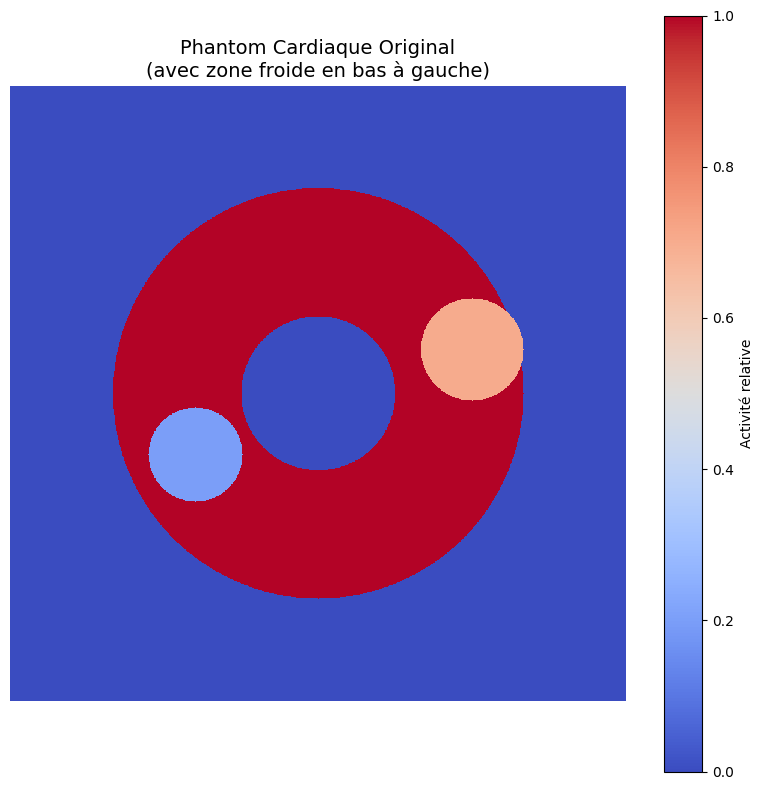

Phantom créé : (1024, 1024)
Valeurs : min=0.00, max=1.00


In [ ]:
phantom = create_cardiac_phantom(1024)

# Affichage
plt.figure(figsize=(8, 8))
plt.imshow(phantom, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Activité relative')
plt.title('Phantom Cardiaque Original\n(avec zone froide en bas à gauche)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Phantom créé : {phantom.shape}")
print(f"Valeurs : min={phantom.min():.2f}, max={phantom.max():.2f}")

<a name="3"></a>
#3. Simulation de l'Acquisition
<a name="3.1"></a>
##3.1. bruit du poisson

En imagerie par émission (SPECT), il existe deux sources principales de "hasard" (bruit) qui suivent une loi de Poisson :

1.  **Le Bruit d'Objet (ce que simule cette cellule) :** La distribution du radiotraceur dans le corps n'est pas une image continue et parfaite. Le traceur est composé de molécules discrètes. Le nombre de molécules radioactives présentes dans chaque petit volume de tissu (voxel) n'est pas une valeur fixe, mais le résultat d'un processus aléatoire. Cette étape simule donc le **bruit intrinsèque à la distribution biologique du traceur**. C'est le réalisme physique de la source.
2.  **Le Bruit de Comptage :** La détection des photons émis par la caméra est également un processus aléatoire. C'est le bruit de la *mesure*.

la fonction `add_poisson_noise(phantom)` (un appel à `np.random.poisson`) est appliquée directement à l'image du `phantom` pour simuler le **"bruit d'objet"**



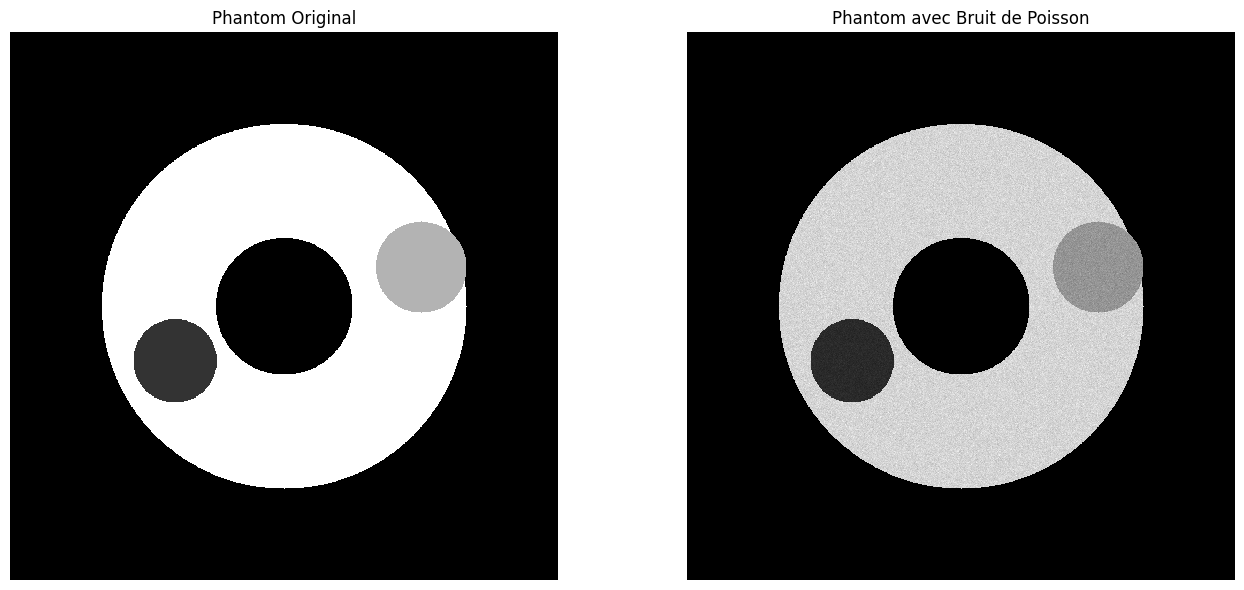

Bruit de Poisson ajouté
SNR approximatif : 26.88 dB


In [ ]:
def add_poisson_noise(image, peak_count=1000):

    image_scaled = image * peak_count

    noisy = np.random.poisson(image_scaled)

    noisy = noisy / peak_count

    return noisy

noisy_phantom = add_poisson_noise(phantom, peak_count=500)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(phantom, cmap='gray', interpolation='nearest')
axes[0].set_title('Phantom Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(noisy_phantom, cmap='gray', interpolation='nearest')
axes[1].set_title('Phantom avec Bruit de Poisson', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Bruit de Poisson ajouté")
print(f"SNR approximatif : {10 * np.log10(np.mean(phantom**2) / np.mean((phantom - noisy_phantom)**2)):.2f} dB")

L'image parfaite  est transformée en une image "granuleuse". Les valeurs de chaque pixel fluctuent maintenant aléatoirement autour de ces moyennes, conformément à la loi de Poisson.

<a name="3.2"></a>
##3.2. Calcul du sinogramme

Simuler l'acquisition physique par la gamma-caméra. La transformation de Radon est le modèle mathématique exact de la projection tomographique, où l'on collecte l'intégrale des valeurs d'intensité le long des lignes de détection à différents angles.

 Le résultat est le sinogramme, qui est l'espace des données brutes en tomographie

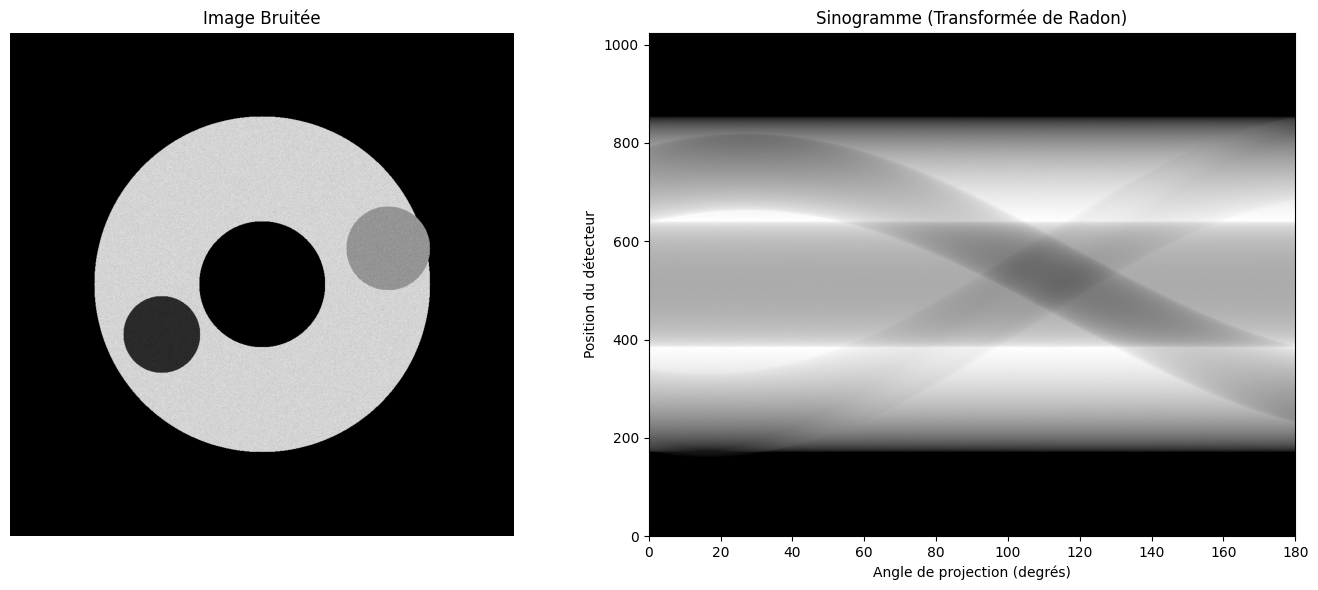

Sinogramme calculé : (1024, 180)
180 projections de 0° à 180°


In [ ]:
def compute_sinogram(image, num_angles=180):
    theta = np.linspace(0, 180, num_angles, endpoint=False)
    sinogram = radon(image, theta=theta, circle=True)
    return sinogram, theta

# Calculer le sinogramme
sinogram, theta = compute_sinogram(noisy_phantom, num_angles=180)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(noisy_phantom, cmap='gray')
axes[0].set_title('Image Bruitée', fontsize=12)
axes[0].axis('off')

axes[1].imshow(sinogram, cmap='gray', aspect='auto', extent=[0, 180, 0, sinogram.shape[0]])
axes[1].set_title('Sinogramme (Transformée de Radon)', fontsize=12)
axes[1].set_xlabel('Angle de projection (degrés)')
axes[1].set_ylabel('Position du détecteur')

plt.tight_layout()
plt.show()

print(f"Sinogramme calculé : {sinogram.shape}")
print(f"{len(theta)} projections de 0° à 180°")

<a name="4"></a>
# 4.Reconstruction Tomographique
L'objectif est de remonter du sinogramme à l'image du cœur

<a name="4.1"></a>
## 4.1. Rétroprojection Filtrée (FBP)
C'est la méthode de reconstruction **analytique** standard. Elle est rapide et mathématiquement directe.

 Cependant, le filtre "rampe" nécessaire pour la FBP a tendance à amplifier les hautes fréquences, **ce qui inclut le bruit de Poisson**. On s'attend à ce que l'image `fbp_result` soit visuellement très bruitée, avec des artefacts en étoile, rendant le diagnostic difficile sans post-traitement.

In [ ]:
def ramp_filter(size):

    n = np.concatenate((np.arange(1, size / 2 + 1, 2, dtype=int),
                        np.arange(size / 2 - 1, 0, -2, dtype=int)))
    f = np.zeros(size)
    f[0] = 0.25
    f[1::2] = -1 / (np.pi * n) ** 2

    return 2 * np.real(np.fft.fft(f))

def fbp_reconstruction(sinogram, theta):

    num_angles = len(theta)
    num_detectors = sinogram.shape[0]

    filter_freq = ramp_filter(num_detectors)

    filtered_sinogram = np.zeros_like(sinogram)
    for i in range(num_angles):
        projection = sinogram[:, i]
        projection_fft = np.fft.fft(projection)
        filtered = np.fft.ifft(projection_fft * filter_freq)
        filtered_sinogram[:, i] = np.real(filtered)

    img_size = num_detectors
    reconstructed = np.zeros((img_size, img_size))

    center = img_size // 2
    x, y = np.mgrid[0:img_size, 0:img_size] - center

    for i, angle in enumerate(theta):
        angle_rad = np.deg2rad(angle)
        t = x * np.cos(angle_rad) + y * np.sin(angle_rad)

        t_indices = t + center
        t_indices = np.clip(t_indices, 0, num_detectors - 1)

        t_floor = np.floor(t_indices).astype(int)
        t_ceil = np.ceil(t_indices).astype(int)
        t_ceil = np.clip(t_ceil, 0, num_detectors - 1)

        weight = t_indices - t_floor

        values = (1 - weight) * filtered_sinogram[t_floor, i] + weight * filtered_sinogram[t_ceil, i]
        reconstructed += values

    reconstructed *= np.pi / (2 * num_angles)

    return reconstructed

Reconstruction FBP et affichage

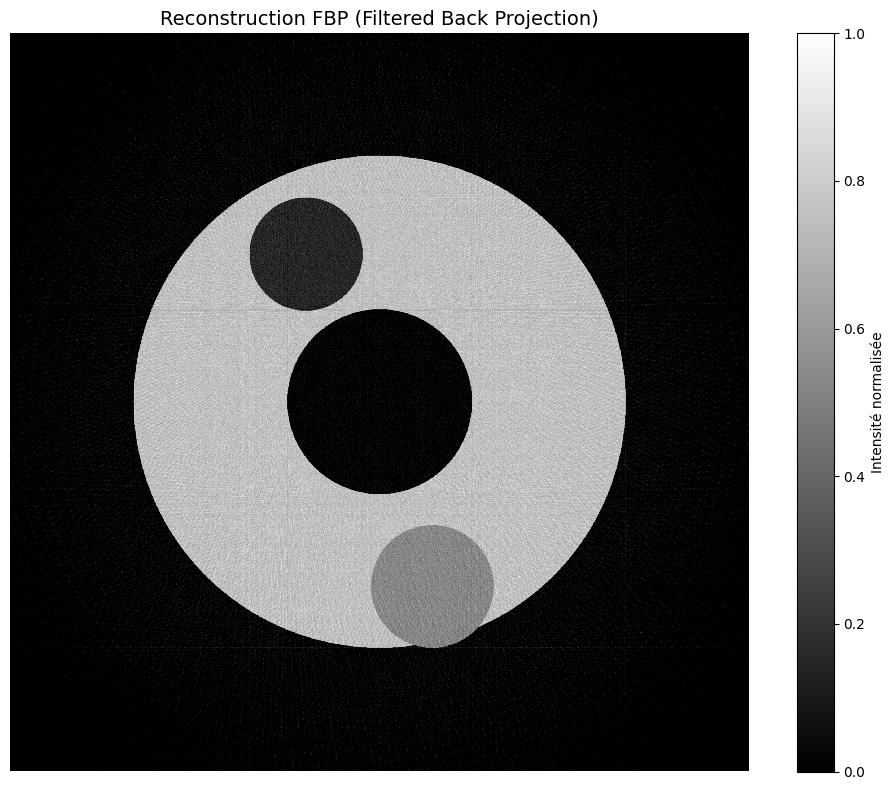

In [ ]:
fbp_result = fbp_reconstruction(sinogram, theta)

fbp_result = np.clip(fbp_result, 0, None)
fbp_result = fbp_result / fbp_result.max()

plt.figure(figsize=(10, 8))
plt.imshow(fbp_result, cmap='gray', interpolation='nearest')
plt.colorbar(label='Intensité normalisée')
plt.title('Reconstruction FBP (Filtered Back Projection)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

<a name="4.2"></a>
##4.2  Reconstruction Itérative SART
C'est une méthode de reconstruction **algébrique**. SART (Simultaneous Algebraic Reconstruction Technique) modélise le problème comme un vaste système d'équations linéaires (où chaque pixel est une inconnue) et le résout de manière itérative. Elle est connue pour être plus robuste que FBP, en particulier lorsque les angles de projection sont limités, **mais elle ne modélise pas intrinsèquement la statistique de Poisson.**


In [ ]:
def forward_project(image, theta):
    return radon(image, theta=theta, circle=True)

def back_project(sinogram, theta, image_size):
    num_angles = len(theta)
    num_detectors = sinogram.shape[0]
    reconstructed = np.zeros((image_size, image_size))

    center = image_size // 2
    x, y = np.mgrid[0:image_size, 0:image_size] - center

    for i, angle in enumerate(theta):
        angle_rad = np.deg2rad(angle)
        t = x * np.cos(angle_rad) + y * np.sin(angle_rad)
        t_indices = t + center
        t_indices = np.clip(t_indices, 0, num_detectors - 1)

        t_floor = np.floor(t_indices).astype(int)
        t_ceil = np.ceil(t_indices).astype(int)
        t_ceil = np.clip(t_ceil, 0, num_detectors - 1)

        weight = t_indices - t_floor
        values = (1 - weight) * sinogram[t_floor, i] + weight * sinogram[t_ceil, i]
        reconstructed += values

    return reconstructed / num_angles

def sart_reconstruction(sinogram, theta, num_iterations=10, relaxation=0.15):

    image_size = sinogram.shape[0]
    reconstructed = np.zeros((image_size, image_size))

    for iteration in range(num_iterations):
        # Forward projection de l'estimation actuelle
        estimated_sinogram = forward_project(reconstructed, theta)

        # Calculer la différence
        difference = sinogram - estimated_sinogram

        # Back projection de la différence
        correction = back_project(difference, theta, image_size)

        # Mise à jour avec relaxation
        reconstructed += relaxation * correction

        # Contrainte de positivité
        reconstructed = np.clip(reconstructed, 0, None)

        if (iteration + 1) % 2 == 0:
            print(f"  Itération {iteration + 1}/{num_iterations}")

    return reconstructed

Reconstruction SART et affichage

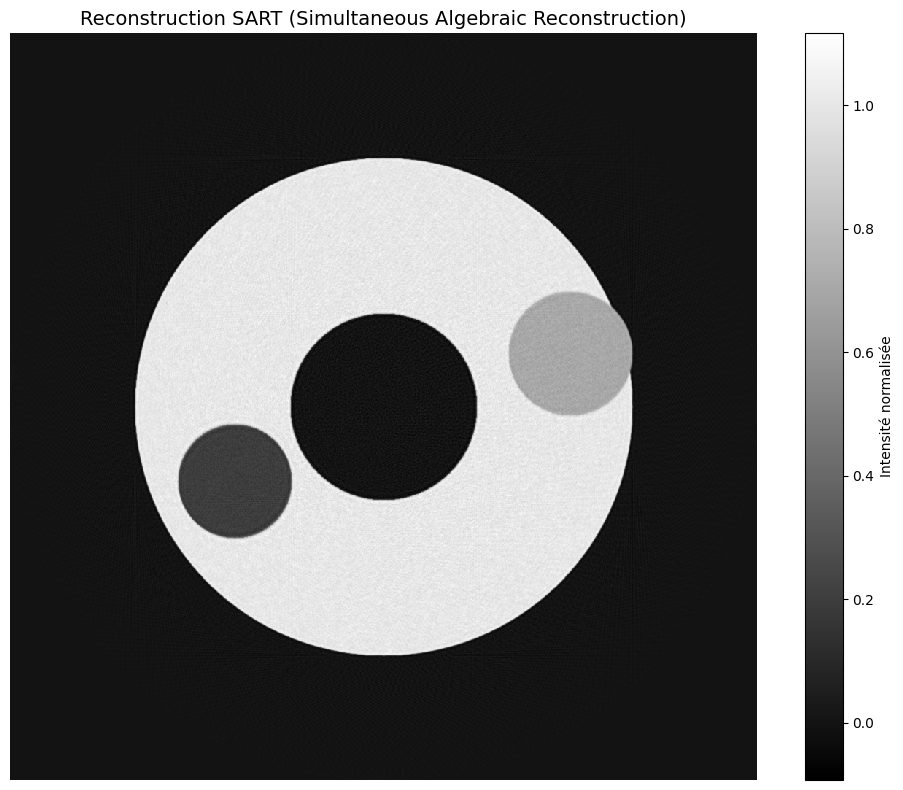

In [ ]:
sart_result = sart_reconstruction(sinogram, theta, num_iterations=10, relaxation=0.15)
sart_result = sart_result / sart_result.max()

plt.figure(figsize=(10, 8))
plt.imshow(sart_result, cmap='gray', interpolation='nearest')
plt.colorbar(label='Intensité normalisée')
plt.title('Reconstruction SART (Simultaneous Algebraic Reconstruction)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

<a name="4.3"></a>
## 4.3. Reconstruction Itérative MLEM (Maximum Likelihood Expectation Maximization)

 c'est une méthode **statistique** de référence en tomographie par émission. L'objectif du MLEM n'est pas de résoudre un système linéaire, mais de trouver l'image de reconstruction qui a la **probabilité maximale** (Maximum Likelihood) d'avoir produit le sinogramme bruité mesuré, **en utilisant explicitement le modèle de bruit de Poisson**. On s'attend à ce que MLEM gère le bruit de manière supérieure, en produisant des images avec un meilleur contraste et moins de bruit structurel, au prix d'un temps de calcul plus long.

In [ ]:
def mlem_reconstruction(sinogram, theta, num_iterations=30):

    image_size = sinogram.shape[0]

    reconstructed = np.ones((image_size, image_size)) * 0.01

    ones_sino = np.ones_like(sinogram)
    sensitivity = iradon(ones_sino, theta=theta, circle=True, filter_name=None)

    if sensitivity.shape != reconstructed.shape:
        from skimage.transform import resize
        sensitivity = resize(sensitivity, reconstructed.shape, anti_aliasing=True)

    sensitivity[sensitivity < 1e-6] = 1e-6

    print(f"MLEM: {num_iterations} itérations")

    for iteration in range(num_iterations):
        estimated_sinogram = radon(reconstructed, theta=theta, circle=True)

        if estimated_sinogram.shape != sinogram.shape:

            from scipy.interpolate import interp1d
            x_old = np.linspace(0, 1, estimated_sinogram.shape[0])
            x_new = np.linspace(0, 1, sinogram.shape[0])
            estimated_sinogram_new = np.zeros_like(sinogram)

            for i in range(estimated_sinogram.shape[1]):
                f = interp1d(x_old, estimated_sinogram[:, i], kind='linear', fill_value='extrapolate')
                estimated_sinogram_new[:, i] = f(x_new)
            estimated_sinogram = estimated_sinogram_new

        estimated_sinogram[estimated_sinogram < 1e-10] = 1e-10

        ratio = sinogram / estimated_sinogram

        correction = iradon(ratio, theta=theta, circle=True, filter_name=None)

        if correction.shape != reconstructed.shape:
            from skimage.transform import resize
            correction = resize(correction, reconstructed.shape, anti_aliasing=True)

        reconstructed = reconstructed * (correction / sensitivity)

        reconstructed = np.clip(reconstructed, 0, None)

        if (iteration + 1) % 5 == 0:
            print(f"  Itération {iteration + 1}/{num_iterations}")

    return reconstructed

Reconstruction MLEM et affichage

MLEM: 60 itérations
  Itération 5/60
  Itération 10/60
  Itération 15/60
  Itération 20/60
  Itération 25/60
  Itération 30/60
  Itération 35/60
  Itération 40/60
  Itération 45/60
  Itération 50/60
  Itération 55/60
  Itération 60/60


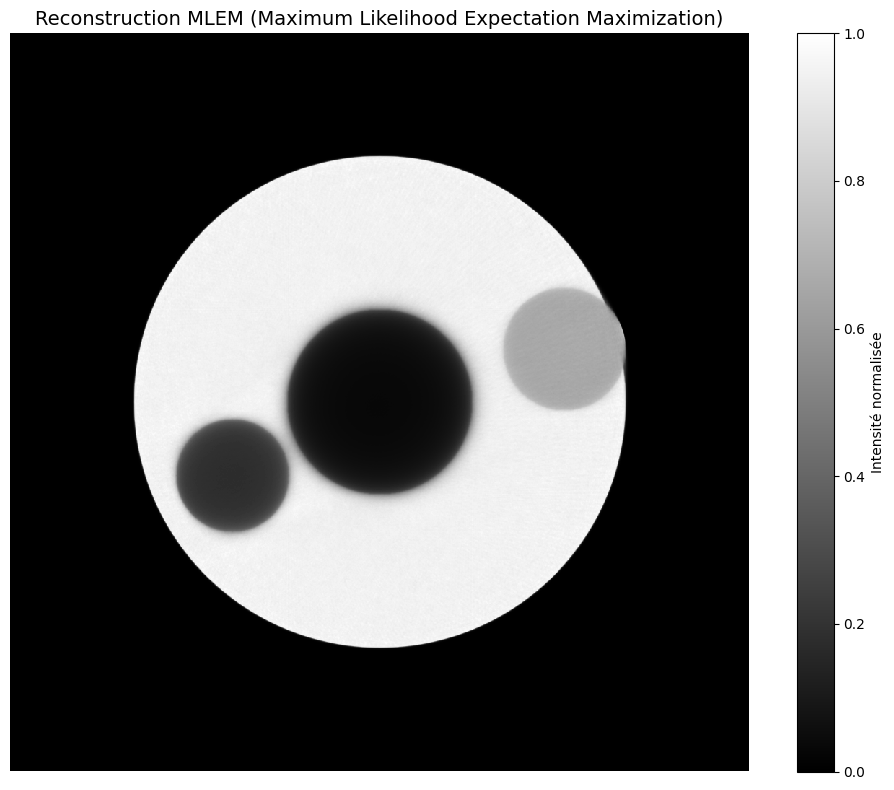

In [ ]:
mlem_result = mlem_reconstruction(sinogram, theta, num_iterations=60)
mlem_result = mlem_result / mlem_result.max()

plt.figure(figsize=(10, 8))
plt.imshow(mlem_result, cmap='gray', interpolation='nearest')
plt.colorbar(label='Intensité normalisée')
plt.title('Reconstruction MLEM (Maximum Likelihood Expectation Maximization)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

<a name="5"></a>
#5. Post-traitement : Débruitage

**Objectif :** Simuler l'étape clinique de **post-filtrage**. Les images reconstruites, même par des méthodes itératives, peuvent être bruitées. Pour améliorer la qualité visuelle et la capacité de diagnostic, un filtre de débruitage est appliqué. Le filtre de Wiener tente de réduire le bruit tout en préservant les structures. Le défi est de trouver le bon équilibre : un filtrage excessif peut **flouter l'image et masquer le défaut de perfusion** (faux négatif), tandis qu'un filtrage insuffisant laisse le bruit obscurcir le diagnostic.

In [ ]:
from scipy.signal import wiener

def denoise_image(image, method='gaussian', **kwargs):

    if method == 'gaussian':
        sigma = kwargs.get('sigma', 1.0)
        return ndimage.gaussian_filter(image, sigma=sigma)
    elif method == 'weiner':
        if noise_variance is None:
            sigma_noise = np.median(np.abs(image - np.median(image))) / 0.6745
            noise_variance = sigma_noise ** 2

        window_size = int(2 * sigma + 1)
        if window_size % 2 == 0:
            window_size += 1

        image_debruitee = wiener(image, mysize=(window_size, window_size),
                                  noise=noise_variance)

        image_debruitee = np.clip(image_debruitee, 0, None)
        if image_debruitee.max() > 0:
            image_debruitee = image_debruitee / image_debruitee.max() * image.max()
    else:
        return image

Débruitage des deux reconstructions et Affichage

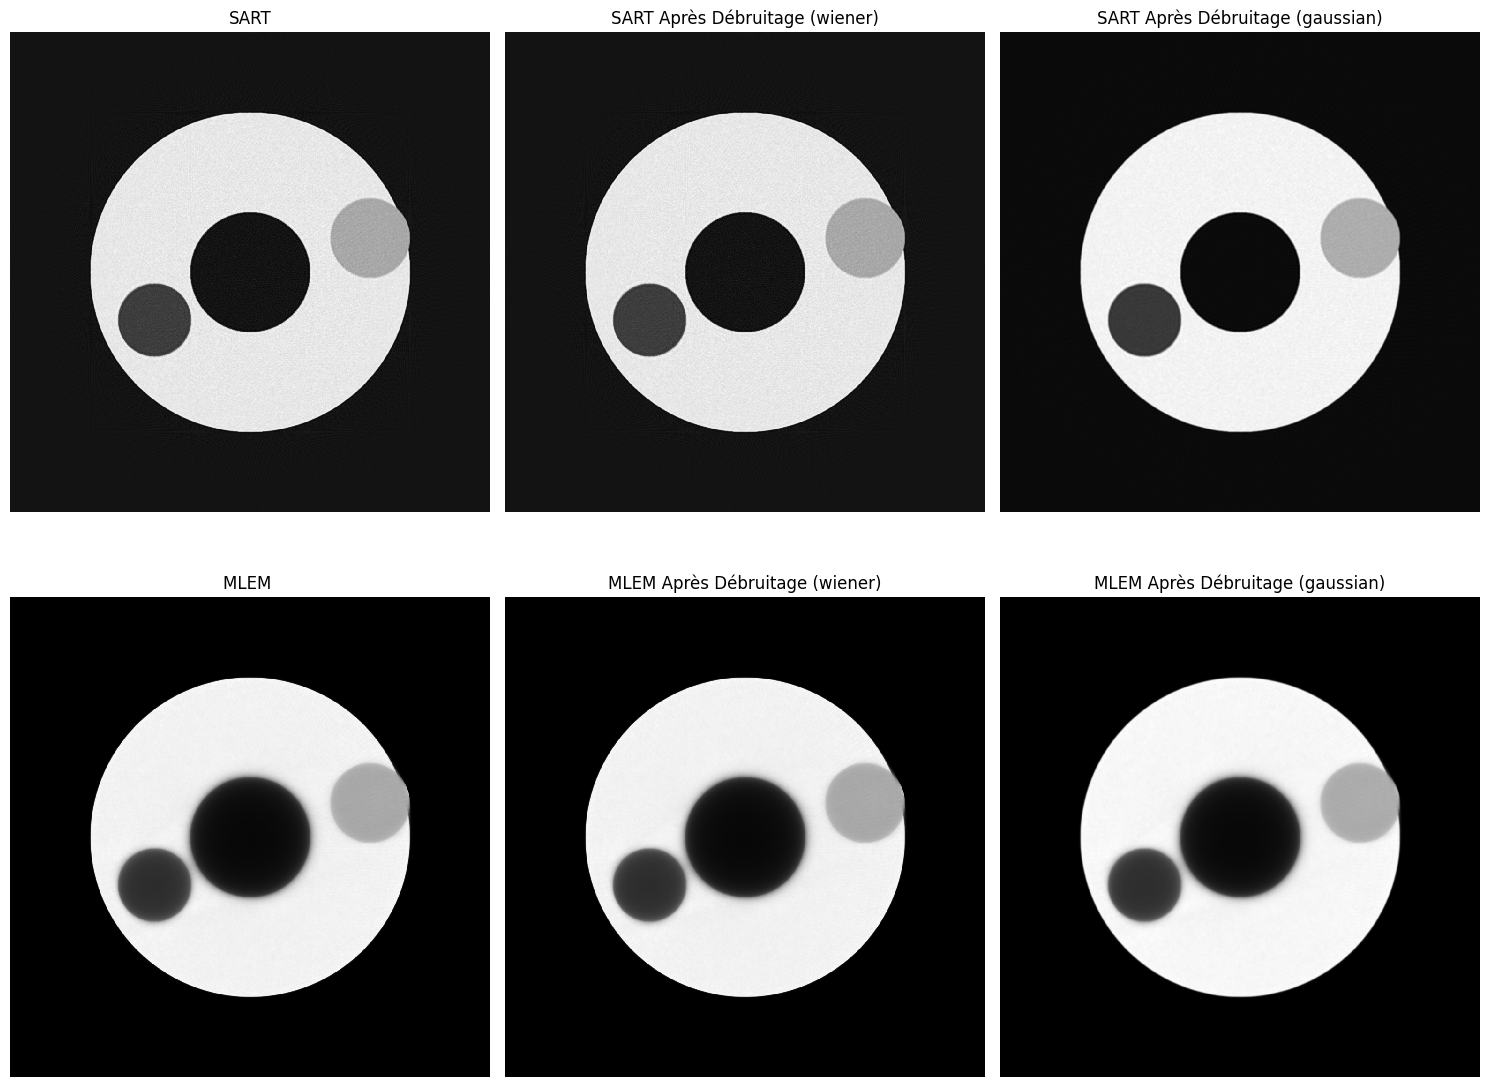

In [ ]:
sart_denoised_wiener = denoise_image(sart_result, method='wiener', sigma=1.5)
sart_denoised_gaussian = denoise_image(sart_result, method='gaussian', sigma=1)

mlem_denoised_wiener = denoise_image(mlem_result, method='wiener', sigma=1)
mlem_denoised_gaussian  = denoise_image(mlem_result, method='gaussian', sigma=1)


fig, axes = plt.subplots(2, 3, figsize=(15, 12))

axes[0, 0].imshow(sart_result, cmap='gray', interpolation='nearest')
axes[0, 0].set_title('SART', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(sart_denoised_wiener, cmap='gray', interpolation='nearest')
axes[0, 1].set_title('SART Après Débruitage (wiener)', fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(sart_denoised_gaussian, cmap='gray', interpolation='nearest')
axes[0, 2].set_title('SART Après Débruitage (gaussian)', fontsize=12)
axes[0, 2].axis('off')

axes[1, 0].imshow(mlem_result, cmap='gray', interpolation='nearest')
axes[1, 0].set_title('MLEM ', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(mlem_denoised_wiener, cmap='gray', interpolation='nearest')
axes[1, 1].set_title('MLEM Après Débruitage (wiener)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(mlem_denoised_gaussian, cmap='gray', interpolation='nearest')
axes[1, 2].set_title('MLEM Après Débruitage (gaussian)', fontsize=12)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

Les résultats montrent que le filtre de Wiener réduit plus efficacement le bruit tout en préservant les détails, contrairement au filtre gaussien qui lisse excessivement l’image. Bien que la reconstruction MLEM paraisse légèrement plus floue, elle présente une meilleure homogénéité et un contraste plus fidèle, offrant ainsi une image plus stable et réaliste.

<a name="6"></a>
# 6. Détection des Zones Froides

La fonction `detect_cold_zones` applique un seuil simple et calcule l'activité moyenne du myocarde et définit comme "froide" toute zone dont l'intensité est inférieure à un pourcentage de cette moyenne. Un masque binaire du défaut détecté est créé.

**Objectif :** Simuler l'étape finale du **diagnostic clinique**. Le but ultime de l'examen n'est pas l'image elle-même, mais la réponse à la question : "Y a-t-il une zone d'ischémie ?".

Cette fonction simule une méthode simple de **segmentation semi-automatique**. En appliquant cette détection aux différentes images, ont: démontre visuellement comment la qualité de la reconstruction (due à l'algorithme) et le post-traitement (débruitage) **impactent directement la capacité à détecter correctement le défaut** (sa taille, sa forme et sa localisation).

In [ ]:
def detect_cold_zones(image, threshold=0.4):

    image_norm = (image - image.min()) / (image.max() - image.min())
    active_region = image_norm > 0.2
    cold_zones = active_region & (image_norm < threshold)

    return cold_zones

Affichage

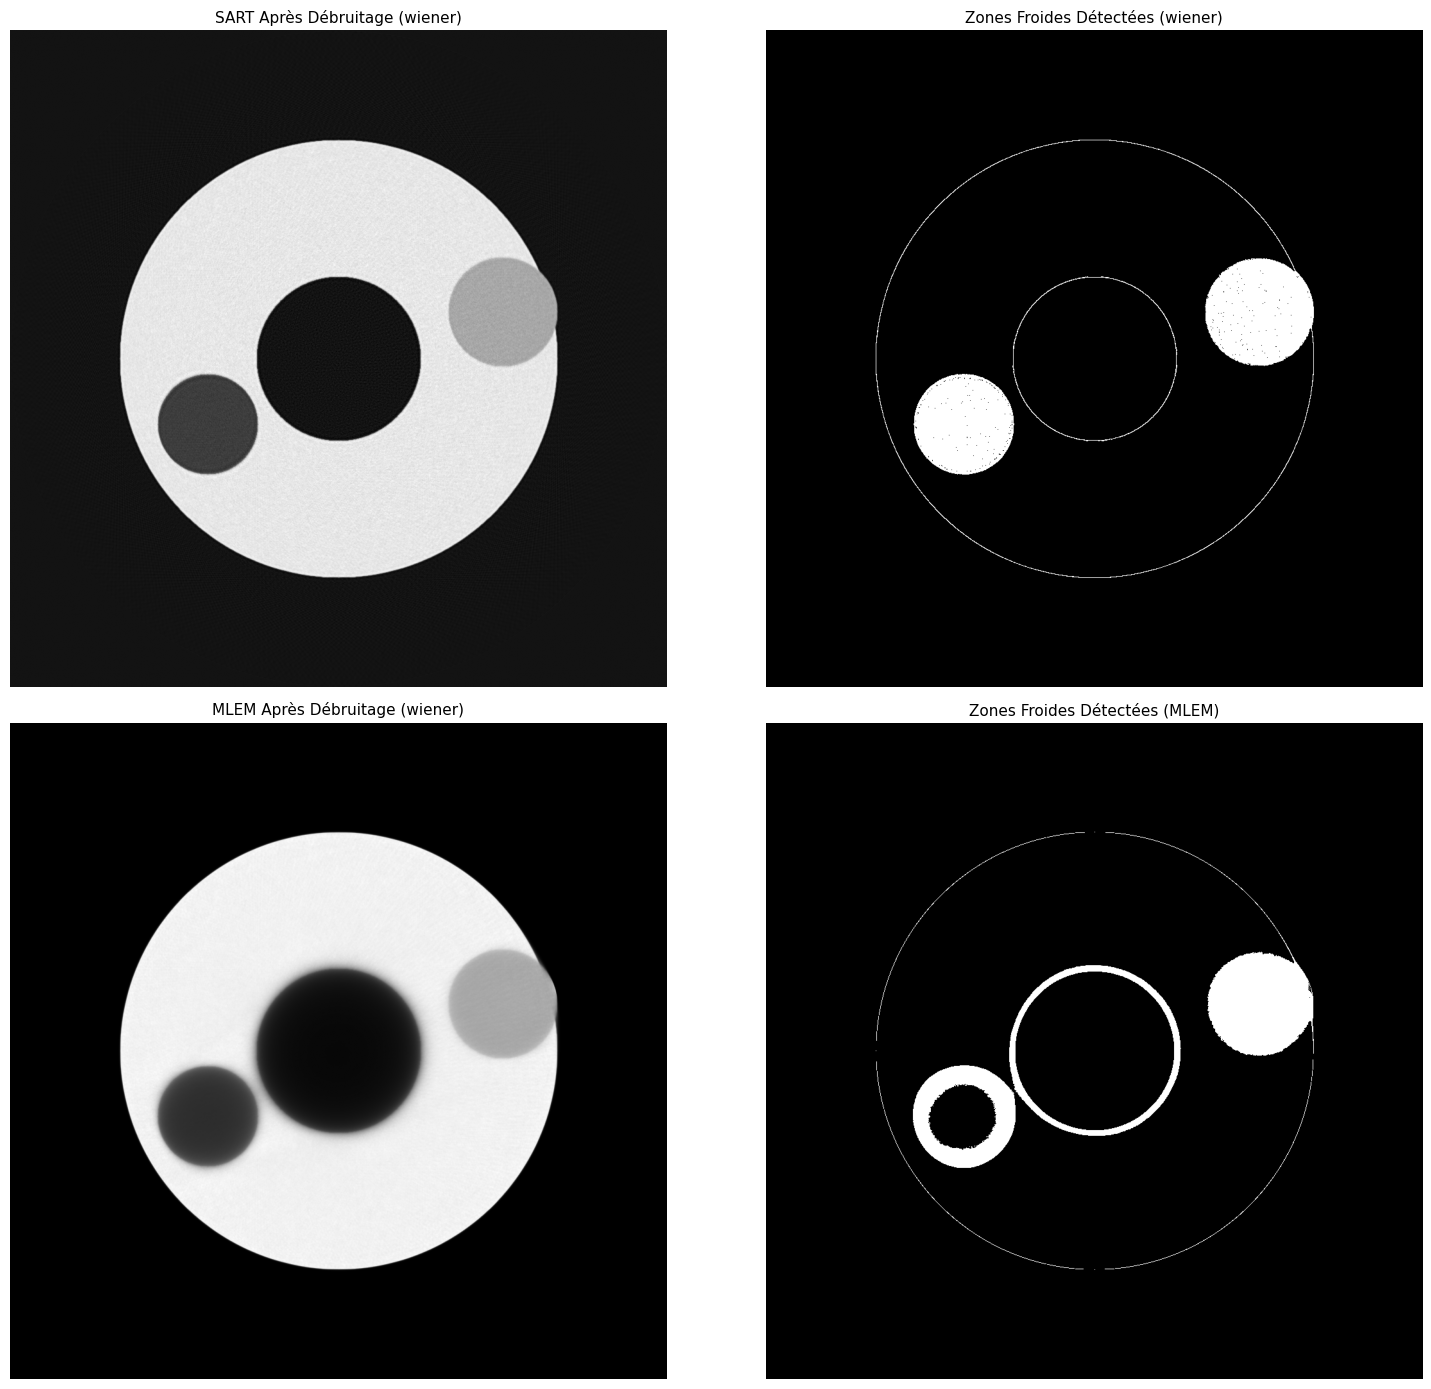

In [ ]:
cold_sart_wiener = detect_cold_zones(sart_denoised_wiener, threshold=0.7)
cold_mlem_result = detect_cold_zones(mlem_denoised_wiener, threshold=0.7)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

axes[0, 0].imshow(sart_denoised_wiener, cmap='gray')
axes[0, 0].set_title('SART Après Débruitage (wiener)', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(cold_sart_wiener, cmap='gray')
axes[0, 1].set_title('Zones Froides Détectées (wiener)', fontsize=11)
axes[0, 1].axis('off')

axes[1, 0].imshow(mlem_result, cmap='gray')
axes[1, 0].set_title('MLEM Après Débruitage (wiener)', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(cold_mlem_result, cmap='gray')
axes[1, 1].set_title('Zones Froides Détectées (MLEM)', fontsize=11)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

En remarquant des régions larges et homogènes blanches dans le résultat, on peut conclure qu’il s’agit de zones froides réelles, correspondant à des régions du myocarde présentant une activité radioactive réduite, donc une mauvaise perfusion sanguine. En scintigraphie cardiaque, ces zones traduisent généralement une ischémie ou un infarctus myocardique, selon la gravité et la réversibilité du défaut.

Ces surfaces blanches représentent donc **les anomalies simulées** dans le modèle cardiaque, tandis que les petits points isolés visibles ailleurs ne sont que du bruit résiduel sans signification clinique.

<a name="7"></a>
# 7. Résultats et Discussion

La qualité des images reconstruites est évaluée en les comparant au phantom original à l'aide de métriques courantes:




- **MSE (Erreur Quadratique Moyenne) :** Calcule la moyenne des erreurs au carré entre chaque pixel de l'image reconstruite et l'originale.

- **PSNR (Rapport Signal/Bruit de Crête) :** Mesure la qualité de la reconstruction en évaluant le rapport entre la puissance maximale du signal et la puissance du bruit (erreur).

- **SSIM (Indice de Similarité Structurelle) :** Évalue à quel point l'image reconstruite "ressemble" à l'originale du point de vue de la perception humaine (structure, contraste, luminance).

- **MAE (Erreur Absolue Moyenne) :** Calcule la moyenne des différences absolues (non carrées) entre les pixels des deux images.

In [ ]:
def calculate_metrics(original, reconstructed):

    original_norm = (original - original.min()) / (original.max() - original.min())
    reconstructed_norm = (reconstructed - reconstructed.min()) / (reconstructed.max() - reconstructed.min())

    mse = np.mean((original_norm - reconstructed_norm) ** 2)

    if mse > 0:
        psnr = 20 * np.log10(1.0 / np.sqrt(mse))
    else:
        psnr = float('inf')

    ssim_value = ssim(original_norm, reconstructed_norm, data_range=1.0)

    mae = np.mean(np.abs(original_norm - reconstructed_norm))

    relative_error = np.linalg.norm(original_norm - reconstructed_norm) / np.linalg.norm(original_norm)

    return {
        'MSE': mse,
        'PSNR': psnr,
        'SSIM': ssim_value,
        'MAE': mae,
        'Erreur Relative': relative_error
    }

Affichage des résultats

In [ ]:
metrics_mlem = calculate_metrics(phantom, mlem_denoised_wiener)
metrics_sart_denoised_wiener = calculate_metrics(phantom, sart_denoised_wiener)

print("MÉTRIQUES D'ÉVALUATION")
print("-" * 100)
print(f"{'Métrique':<20} {'MLEM Après Débruitage (wiener)':>9}           {'SART Après Débruitage (wiener)':>20}")
print("-" * 100)
for metric in metrics_mlem.keys():
    print(f"{metric:<20} {metrics_mlem[metric]:>10.6f} {metrics_sart_denoised_wiener[metric]:>50.6f}")


MÉTRIQUES D'ÉVALUATION
----------------------------------------------------------------------------------------------------
Métrique             MLEM Après Débruitage (wiener)           SART Après Débruitage (wiener)
----------------------------------------------------------------------------------------------------
MSE                    0.003316                                           0.007226
PSNR                  24.793799                                          21.411194
SSIM                   0.918142                                           0.242640
MAE                    0.024972                                           0.081466
Erreur Relative        0.110539                                           0.163172




En comparant les résultats obtenus après débruitage par filtre de Wiener pour les deux méthodes de reconstruction, **MLEM** et **SART**, on observe que, malgré un **aspect visuel légèrement plus flou** dans l’image issue de la méthode **MLEM**, celle-ci présente **de meilleures performances quantitatives**.

En effet, les métriques d’évaluation démontrent clairement la **supériorité de MLEM** en termes de **fidélité et de préservation des structures**.

 Cette observation montre que le flou perçu n’affecte pas la qualité réelle du signal reconstruit et que **MLEM, associé à un débruitage Wiener, fournit la meilleure configuration globale** pour les étapes d’analyse ultérieures, notamment la détection fiable des zones froides myocardiques.



<a name="8"></a>
# 8. Conclusion Générale

Ce travail a permis d’explorer l’ensemble du processus de **reconstruction d’une image scintigraphique cardiaque**, depuis la **simulation du sinogramme** jusqu’à la **détection automatique des zones froides**.

Les comparaisons entre les différentes méthodes de reconstruction ont montré que, bien que la méthode **SART** produise des images plus nettes visuellement, la méthode **MLEM**, surtout lorsqu’elle est associée à un **débruitage par filtre de Wiener**, offre les **meilleures performances quantitatives** et la **reconstruction la plus fidèle** au modèle réel.

Le débruitage a joué un rôle essentiel en réduisant efficacement le bruit tout en préservant la structure myocardique, condition nécessaire à une analyse fiable.

Enfin, la détection des zones froides a permis d’identifier les **régions d’hypoperfusion** simulées, illustrant l’utilité de cette chaîne de traitement pour le **diagnostic fonctionnel du myocarde**.


Ainsi, cette étude permet de recommander la **combinaison de la méthode MLEM avec le filtre de Wiener** comme **configuration optimale** pour la **reconstruction, le débruitage et l’analyse quantitative** en imagerie scintigraphique cardiaque, grâce à son équilibre entre **fidélité de reconstruction**, **réduction du bruit** et **préservation des structures myocardiques**.






---

